<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/well/well_nodal_analysis_and_eclipse_vfp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Well nodal analysis: IPR, lift curves, operating point, and ECLIPSE VFPPROD

This executable tutorial connects reservoir inflow and wellbore lift in NeqSim. It makes
the operating point visible as the intersection of the inflow-performance relationship
(IPR) and vertical-lift-performance (VLP) curve, then reuses the NeqSim VLP calculations
to generate an ECLIPSE-style `VFPPROD` include file.

**Learning objectives**

- distinguish reservoir pressure, flowing bottom-hole pressure, and tubing-head pressure;
- calculate gas-well IPR and VLP curves with the released `WellSystem` API;
- solve and independently verify the IPR–VLP crossing;
- explain how pressure, tubing size, and depletion move the operating point;
- generate a family of lift curves over flow rate and tubing-head pressure; and
- map the calculated grid into ECLIPSE `VFPPROD` dimensions and export syntax.

## Source, scope, and engineering basis

The conceptual structure follows the NeqSim field-development and operations book:
[Field Development and Operations with NeqSim](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html).
The implementation is checked against the current
[NeqSim well simulation guide](https://equinor.github.io/neqsim/simulation/well_simulation_guide)
and released Java APIs.

The example is a synthetic vertical gas producer. Pressures are absolute. Standard gas
rates are reported in million standard cubic metres per day (MSm³/day). The data are
educational and contain no proprietary field information.

`WellSystem.VLPSolverMode.SIMPLIFIED` is deliberately used for the complete nodal and VFP
grid so the notebook is fast and deterministic in Colab. It evaluates NeqSim
thermodynamic properties and combines hydrostatic and frictional pressure losses. A final
design table must be calibrated against pressure surveys and regenerated with a qualified
multiphase well model when liquid loading, slip, completion details, or terrain matter.

## 1. Colab setup

The setup remains public-PyPI compatible. During repository validation this cell detects
the already bootstrapped clean environment and does not access the network.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "neqsim"]
    )

In [2]:
from importlib.metadata import version
from pathlib import Path

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim


SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
WellSystem = jneqsim.process.equipment.reservoir.WellSystem
EclipseVFPExporter = jneqsim.process.util.optimizer.EclipseVFPExporter

neqsim_version = version("neqsim")
python_version = sys.version.split()[0]
java_version = str(
    jpype.JClass("java.lang.System").getProperty("java.version")
)

print(f"NeqSim {neqsim_version}")
print(f"Python {python_version}")
print(f"Java {java_version}")

NeqSim 3.16.0
Python 3.12.13
Java 17.0.19


## 2. Nodal-analysis equations

### Reservoir inflow

For the gas-well productivity-index model used here, NeqSim applies a squared-pressure
relationship:

$$
q = J\left(p_r^2-p_{wf}^2\right)
$$

Its pressure form is

$$
p_{\mathrm{IPR}}(q)
=
\sqrt{p_r^2-\frac{q}{J}}
$$

where $q$ is standard gas rate, $J$ is productivity index, $p_r$ is reservoir pressure,
and $p_{wf}$ is flowing bottom-hole pressure. The IPR pressure decreases as rate rises.

### Wellbore lift

The VLP curve gives the bottom-hole pressure needed to deliver a requested rate against a
specified tubing-head pressure:

$$
p_{\mathrm{VLP}}(q)
=
p_{thp}
+\Delta p_h(q)
+\Delta p_f(q)
+\Delta p_a(q)
$$

The terms are hydrostatic, frictional, and acceleration pressure changes. In this
screening solver the first two dominate.

### Operating point

The sustainable steady operating rate $q^*$ is the root of

$$
f(q)
=
p_{\mathrm{IPR}}(q)
-p_{\mathrm{VLP}}(q)
=0
$$

Graphically, this is exactly where the descending IPR and rising VLP curves cross.

## 3. Fluid and well definition

The SRK fluid is a synthetic wet gas at reservoir conditions. The well has a 2,800 m
vertical tubing string, 4.5 inch internal diameter, 50 bara tubing-head pressure, and a
productivity index chosen to give a 5.0 MSm³/day absolute-open-flow indicator at 250 bara.
Every sensitivity creates a fresh fluid, stream, and well so no flashed state leaks from
one case into another.

In [3]:
GAS_COMPOSITION = {
    "methane": 0.840,
    "ethane": 0.080,
    "propane": 0.040,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-pentane": 0.010,
    "n-hexane": 0.005,
}

RESERVOIR_PRESSURE_BARA = 250.0
RESERVOIR_TEMPERATURE_C = 85.0
PRODUCTIVITY_INDEX = 80.0
TUBING_LENGTH_M = 2_800.0
TUBING_DIAMETER_IN = 4.5
TUBING_ROUGHNESS_M = 2.5e-5
TUBING_INCLINATION_DEG = 90.0
TUBING_HEAD_PRESSURE_BARA = 50.0
WELLHEAD_TEMPERATURE_C = 25.0


def make_reservoir_stream(reservoir_pressure_bara):
    fluid = SystemSrkEos(
        RESERVOIR_TEMPERATURE_C + 273.15,
        reservoir_pressure_bara,
    )
    for component, fraction in GAS_COMPOSITION.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.init(0)

    stream = Stream("synthetic reservoir stream", fluid)
    stream.setFlowRate(4.0, "MSm3/day")
    stream.run()
    return stream


def make_well(
    reservoir_pressure_bara=RESERVOIR_PRESSURE_BARA,
    tubing_head_pressure_bara=TUBING_HEAD_PRESSURE_BARA,
    tubing_diameter_in=TUBING_DIAMETER_IN,
):
    reservoir_stream = make_reservoir_stream(
        reservoir_pressure_bara
    )
    well = WellSystem("Producer A", reservoir_stream)
    well.setIPRModel(WellSystem.IPRModel.PRODUCTION_INDEX)
    well.setProductionIndex(
        PRODUCTIVITY_INDEX,
        "Sm3/day/bar2",
    )
    well.setTubingLength(TUBING_LENGTH_M, "m")
    well.setTubingDiameter(tubing_diameter_in, "in")
    well.setTubingRoughness(TUBING_ROUGHNESS_M)
    well.setInclination(TUBING_INCLINATION_DEG)
    well.setBottomHoleTemperature(
        RESERVOIR_TEMPERATURE_C,
        "C",
    )
    well.setWellheadTemperature(
        WELLHEAD_TEMPERATURE_C,
        "C",
    )
    well.setWellheadPressure(
        tubing_head_pressure_bara,
        "bara",
    )
    well.setVLPSolverMode(
        WellSystem.VLPSolverMode.SIMPLIFIED
    )
    return well


reservoir_stream = make_reservoir_stream(
    RESERVOIR_PRESSURE_BARA
)
reservoir_fluid = reservoir_stream.getFluid()
fluid_summary = pd.DataFrame(
    {
        "Quantity": [
            "Reservoir pressure",
            "Reservoir temperature",
            "Phases at reservoir conditions",
            "Fluid molar mass",
            "Fluid density",
        ],
        "Value": [
            reservoir_stream.getPressure("bara"),
            reservoir_stream.getTemperature("C"),
            reservoir_fluid.getNumberOfPhases(),
            reservoir_fluid.getMolarMass() * 1_000.0,
            reservoir_fluid.getDensity("kg/m3"),
        ],
        "Unit": ["bara", "°C", "-", "g/mol", "kg/m³"],
    }
)
display(fluid_summary)

                         Quantity       Value   Unit
0              Reservoir pressure  250.000000   bara
1           Reservoir temperature   85.000000     °C
2  Phases at reservoir conditions    1.000000      -
3                Fluid molar mass   20.251060  g/mol
4                   Fluid density  186.297468  kg/m³


## 4. Let NeqSim solve the coupled well

`WellSystem.run()` brackets rate between a low-rate point and the IPR limit, evaluates

$$
f(q)=p_{\mathrm{IPR}}(q)-p_{\mathrm{VLP}}(q)
$$

and uses a robust bisection iteration. The outlet stream is created at the specified
tubing-head pressure and solved operating rate.

In [4]:
base_well = make_well()
base_well.run()

api_operating_rate_msm3_day = base_well.getOperatingFlowRate(
    "MSm3/day"
)
api_operating_bhp_bara = base_well.getBottomHolePressure("bara")

base_summary = pd.DataFrame(
    {
        "Quantity": [
            "Reservoir pressure",
            "Tubing-head pressure",
            "Operating rate",
            "Flowing bottom-hole pressure",
            "Reservoir drawdown",
            "Tubing pressure requirement",
        ],
        "Value": [
            base_well.getReservoirPressure("bara"),
            base_well.getWellheadPressure("bara"),
            api_operating_rate_msm3_day,
            api_operating_bhp_bara,
            base_well.getDrawdown("bar"),
            api_operating_bhp_bara
            - base_well.getWellheadPressure("bara"),
        ],
        "Unit": [
            "bara",
            "bara",
            "MSm³/day",
            "bara",
            "bar",
            "bar",
        ],
    }
)
display(base_summary)

                       Quantity       Value      Unit
0            Reservoir pressure  250.000000      bara
1          Tubing-head pressure   50.000000      bara
2                Operating rate    3.328613  MSm³/day
3  Flowing bottom-hole pressure  144.541807      bara
4            Reservoir drawdown  105.458193       bar
5   Tubing pressure requirement   94.541807       bar


## 5. Calculate and plot the IPR and VLP curves

The integrated API exposes both curves. `generateIPRCurve` returns flow and bottom-hole
pressure from reservoir inflow. `generateVLPCurve` returns the required bottom-hole
pressure for the requested flow grid and current tubing-head boundary.

In [5]:
ipr_curve = np.asarray(
    base_well.generateIPRCurve(101),
    dtype=float,
)
ipr_rate_msm3_day = ipr_curve[0] / 1.0e6
ipr_bhp_bara = ipr_curve[1]

rate_grid_msm3_day = np.linspace(0.05, 4.95, 80)
vlp_curve = np.asarray(
    base_well.generateVLPCurve(
        rate_grid_msm3_day * 1.0e6
    ),
    dtype=float,
)
vlp_bhp_bara = vlp_curve[1]

curve_table = pd.DataFrame(
    {
        "Rate (MSm³/day)": rate_grid_msm3_day,
        "IPR BHP (bara)": np.interp(
            rate_grid_msm3_day,
            ipr_rate_msm3_day,
            ipr_bhp_bara,
        ),
        "VLP BHP (bara)": vlp_bhp_bara,
    }
)
curve_table["Pressure residual (bar)"] = (
    curve_table["IPR BHP (bara)"]
    - curve_table["VLP BHP (bara)"]
)
display(curve_table.iloc[::10].reset_index(drop=True))

   Rate (MSm³/day)  IPR BHP (bara)  VLP BHP (bara)  Pressure residual (bar)
0         0.050000      248.743719       88.161955               160.581763
1         0.670253      232.640290       91.537331               141.102959
2         1.290506      215.332187       98.862642               116.469545
3         1.910759      196.504475      109.464127                87.040348
4         2.531013      175.673310      123.025062                52.648248
5         3.151266      152.013809      139.341215                12.672594
6         3.771519      123.913182      158.264191               -34.351008
7         4.391772       87.190424      179.678715               -92.488291


## 6. Independently locate the curve crossing

The independent solver below uses the same NeqSim-generated curve functions but performs
its own sign-change search and bisection. This is deliberately separate from
`WellSystem.run()` and acts as a convergence certificate.

If $f(q)>0$, reservoir inflow can provide more bottom-hole pressure than the tubing needs,
so rate can rise. If $f(q)<0$, the requested rate is not sustainable. A bracket with
opposite signs therefore contains the operating point.

In [6]:
def ipr_pressure_from_rate(rate_msm3_day):
    rate_sm3_day = rate_msm3_day * 1.0e6
    pressure_squared = (
        RESERVOIR_PRESSURE_BARA**2
        - rate_sm3_day / PRODUCTIVITY_INDEX
    )
    if pressure_squared < 0.0:
        return np.nan
    return float(np.sqrt(pressure_squared))


def vlp_pressure_from_rate(well, rate_msm3_day):
    curve = np.asarray(
        well.generateVLPCurve(
            np.array([rate_msm3_day * 1.0e6])
        ),
        dtype=float,
    )
    return float(curve[1, 0])


def pressure_residual(well, rate_msm3_day):
    return (
        ipr_pressure_from_rate(rate_msm3_day)
        - vlp_pressure_from_rate(well, rate_msm3_day)
    )


def solve_curve_crossing(well, rate_grid):
    residuals = np.array(
        [
            pressure_residual(well, rate)
            for rate in rate_grid
        ]
    )
    crossing_indices = np.where(
        residuals[:-1] * residuals[1:] <= 0.0
    )[0]
    if len(crossing_indices) != 1:
        raise RuntimeError(
            "Expected exactly one IPR-VLP crossing."
        )

    lower = float(rate_grid[crossing_indices[0]])
    upper = float(rate_grid[crossing_indices[0] + 1])
    for _ in range(45):
        middle = 0.5 * (lower + upper)
        if pressure_residual(well, lower) * pressure_residual(
            well,
            middle,
        ) <= 0.0:
            upper = middle
        else:
            lower = middle

    rate = 0.5 * (lower + upper)
    ipr_pressure = ipr_pressure_from_rate(rate)
    vlp_pressure = vlp_pressure_from_rate(well, rate)
    return {
        "rate_msm3_day": rate,
        "ipr_bhp_bara": ipr_pressure,
        "vlp_bhp_bara": vlp_pressure,
        "pressure_residual_bar": ipr_pressure - vlp_pressure,
        "rate_bracket_msm3_day": upper - lower,
    }


crossing = solve_curve_crossing(
    base_well,
    rate_grid_msm3_day,
)
crossing_summary = pd.DataFrame(
    {
        "Quantity": [
            "Independent crossing rate",
            "IPR pressure at crossing",
            "VLP pressure at crossing",
            "Pressure residual",
            "Final rate bracket",
            "Difference from WellSystem.run()",
        ],
        "Value": [
            crossing["rate_msm3_day"],
            crossing["ipr_bhp_bara"],
            crossing["vlp_bhp_bara"],
            crossing["pressure_residual_bar"],
            crossing["rate_bracket_msm3_day"],
            crossing["rate_msm3_day"]
            - api_operating_rate_msm3_day,
        ],
        "Unit": [
            "MSm³/day",
            "bara",
            "bara",
            "bar",
            "MSm³/day",
            "MSm³/day",
        ],
    }
)
display(crossing_summary)

                           Quantity         Value      Unit
0         Independent crossing rate  3.329307e+00  MSm³/day
1          IPR pressure at crossing  1.445118e+02      bara
2          VLP pressure at crossing  1.445118e+02      bara
3                 Pressure residual  0.000000e+00       bar
4                Final rate bracket  1.776357e-15  MSm³/day
5  Difference from WellSystem.run()  6.939052e-04  MSm³/day


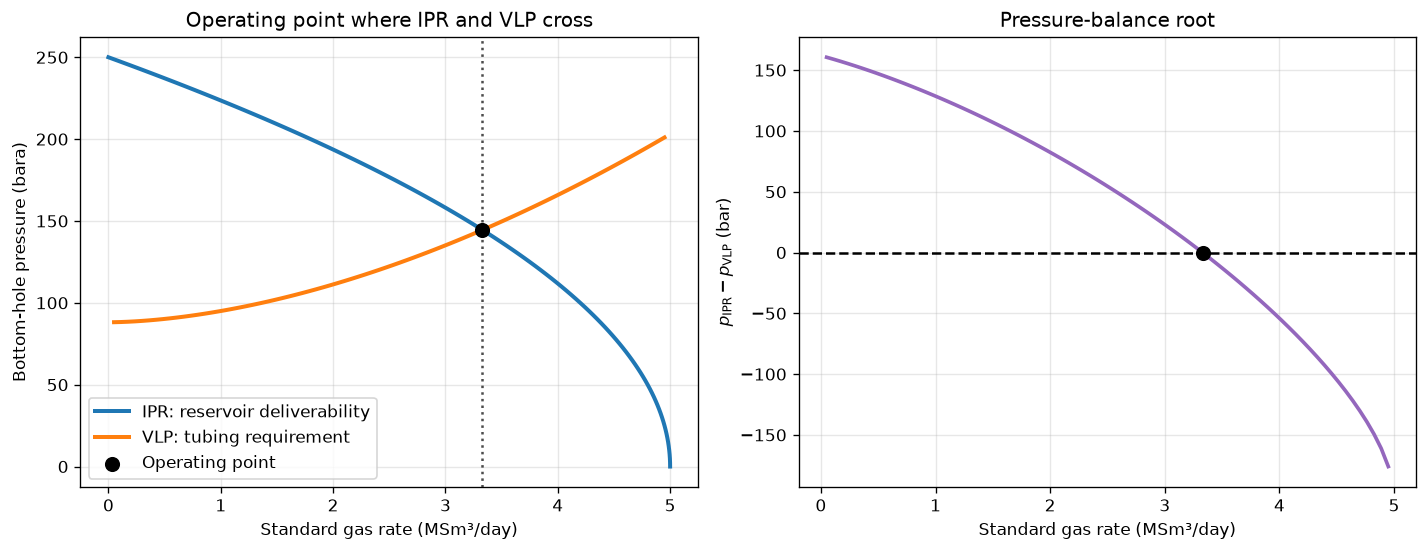

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.7))

axes[0].plot(
    ipr_rate_msm3_day,
    ipr_bhp_bara,
    linewidth=2.4,
    label="IPR: reservoir deliverability",
)
axes[0].plot(
    rate_grid_msm3_day,
    vlp_bhp_bara,
    linewidth=2.4,
    label="VLP: tubing requirement",
)
axes[0].scatter(
    [crossing["rate_msm3_day"]],
    [crossing["ipr_bhp_bara"]],
    color="black",
    s=65,
    zorder=4,
    label="Operating point",
)
axes[0].axvline(
    crossing["rate_msm3_day"],
    color="black",
    linestyle=":",
    alpha=0.7,
)
axes[0].set_xlabel("Standard gas rate (MSm³/day)")
axes[0].set_ylabel("Bottom-hole pressure (bara)")
axes[0].set_title("Operating point where IPR and VLP cross")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    curve_table["Rate (MSm³/day)"],
    curve_table["Pressure residual (bar)"],
    linewidth=2.2,
    color="tab:purple",
)
axes[1].axhline(0.0, color="black", linestyle="--")
axes[1].scatter(
    [crossing["rate_msm3_day"]],
    [0.0],
    color="black",
    s=65,
    zorder=4,
)
axes[1].set_xlabel("Standard gas rate (MSm³/day)")
axes[1].set_ylabel(
    r"$p_{\mathrm{IPR}}-p_{\mathrm{VLP}}$ (bar)"
)
axes[1].set_title("Pressure-balance root")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The left plot is the classic nodal-analysis diagram. The reservoir curve slopes down
because more drawdown is needed for more inflow. The tubing curve slopes up because
friction rises with flow. Their intersection is the only rate at which both subsystems
predict the same flowing bottom-hole pressure.

The residual plot gives the numerical interpretation. Positive residual means unused
reservoir pressure margin; negative residual means the tubing requirement is larger than
the reservoir can supply.

## 7. How operating decisions move the crossing

Three common changes are screened:

1. increasing tubing-head pressure raises the VLP curve and reduces rate;
2. increasing tubing diameter reduces friction and increases rate; and
3. reservoir depletion lowers the IPR curve and reduces deliverability.

Each point below is a new coupled NeqSim solve.

In [8]:
def solve_case(
    reservoir_pressure_bara=RESERVOIR_PRESSURE_BARA,
    tubing_head_pressure_bara=TUBING_HEAD_PRESSURE_BARA,
    tubing_diameter_in=TUBING_DIAMETER_IN,
):
    well = make_well(
        reservoir_pressure_bara=reservoir_pressure_bara,
        tubing_head_pressure_bara=tubing_head_pressure_bara,
        tubing_diameter_in=tubing_diameter_in,
    )
    well.run()
    return {
        "rate_msm3_day": well.getOperatingFlowRate(
            "MSm3/day"
        ),
        "bhp_bara": well.getBottomHolePressure("bara"),
    }


thp_rows = []
for thp in [30.0, 40.0, 50.0, 60.0, 70.0]:
    result = solve_case(tubing_head_pressure_bara=thp)
    thp_rows.append(
        {
            "Tubing-head pressure (bara)": thp,
            "Operating rate (MSm³/day)": result[
                "rate_msm3_day"
            ],
            "Operating BHP (bara)": result["bhp_bara"],
        }
    )

diameter_rows = []
for diameter in [3.5, 4.0, 4.5, 5.0, 5.5]:
    result = solve_case(tubing_diameter_in=diameter)
    diameter_rows.append(
        {
            "Tubing ID (in)": diameter,
            "Operating rate (MSm³/day)": result[
                "rate_msm3_day"
            ],
            "Operating BHP (bara)": result["bhp_bara"],
        }
    )

depletion_rows = []
for pressure in [250.0, 230.0, 210.0, 190.0, 170.0]:
    result = solve_case(reservoir_pressure_bara=pressure)
    depletion_rows.append(
        {
            "Reservoir pressure (bara)": pressure,
            "Operating rate (MSm³/day)": result[
                "rate_msm3_day"
            ],
            "Operating BHP (bara)": result["bhp_bara"],
        }
    )

thp_sensitivity = pd.DataFrame(thp_rows)
diameter_sensitivity = pd.DataFrame(diameter_rows)
depletion_sensitivity = pd.DataFrame(depletion_rows)

display(thp_sensitivity)
display(diameter_sensitivity)
display(depletion_sensitivity)

   Tubing-head pressure (bara)  Operating rate (MSm³/day)  Operating BHP (bara)
0                         30.0                   3.574707            133.477197
1                         40.0                   3.456787            138.889025
2                         50.0                   3.328613            144.541807
3                         60.0                   3.191895            150.337349
4                         70.0                   3.044922            156.328105
   Tubing ID (in)  Operating rate (MSm³/day)  Operating BHP (bara)
0             3.5                   2.282715            184.298846
1             4.0                   2.856934            163.671409
2             4.5                   3.328613            144.541807
3             5.0                   3.673828            128.752275
4             5.5                   3.906250            116.926793
   Reservoir pressure (bara)  Operating rate (MSm³/day)  Operating BHP (bara)
0                      250.0            

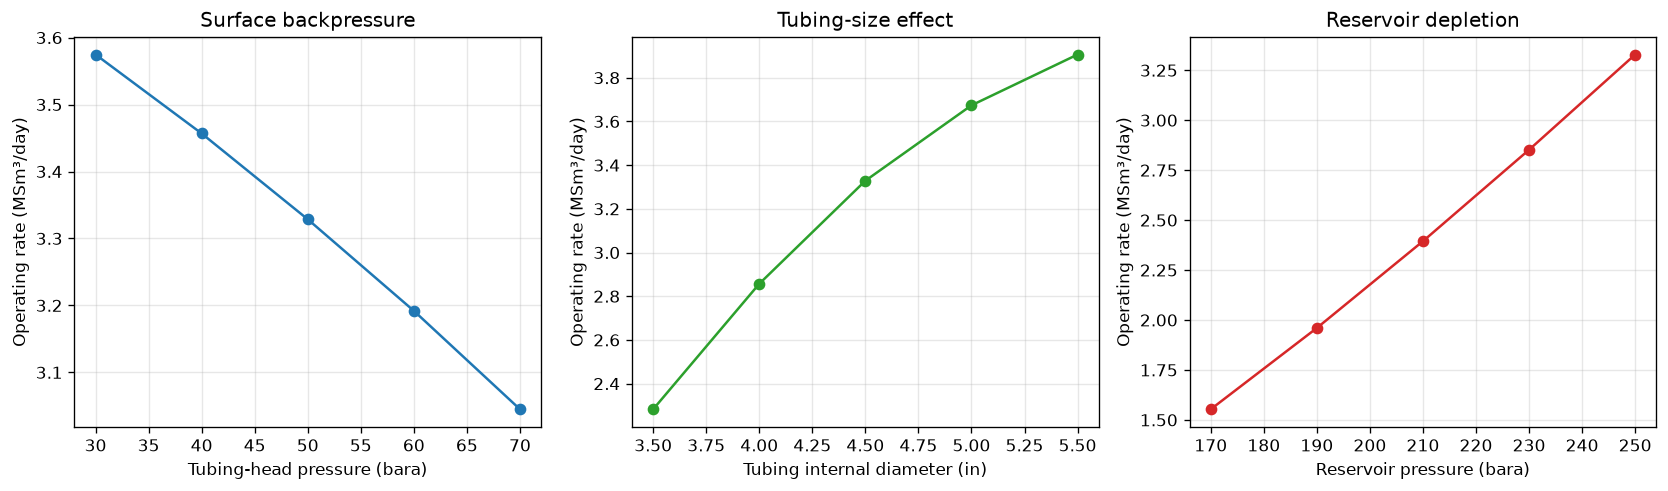

In [9]:
figure, axes = plt.subplots(1, 3, figsize=(14.0, 4.2))

axes[0].plot(
    thp_sensitivity["Tubing-head pressure (bara)"],
    thp_sensitivity["Operating rate (MSm³/day)"],
    marker="o",
)
axes[0].set_xlabel("Tubing-head pressure (bara)")
axes[0].set_ylabel("Operating rate (MSm³/day)")
axes[0].set_title("Surface backpressure")
axes[0].grid(alpha=0.3)

axes[1].plot(
    diameter_sensitivity["Tubing ID (in)"],
    diameter_sensitivity["Operating rate (MSm³/day)"],
    marker="o",
    color="tab:green",
)
axes[1].set_xlabel("Tubing internal diameter (in)")
axes[1].set_ylabel("Operating rate (MSm³/day)")
axes[1].set_title("Tubing-size effect")
axes[1].grid(alpha=0.3)

axes[2].plot(
    depletion_sensitivity["Reservoir pressure (bara)"],
    depletion_sensitivity["Operating rate (MSm³/day)"],
    marker="o",
    color="tab:red",
)
axes[2].set_xlabel("Reservoir pressure (bara)")
axes[2].set_ylabel("Operating rate (MSm³/day)")
axes[2].set_title("Reservoir depletion")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. From lift curves to an ECLIPSE VFPPROD table

Reservoir simulators do not normally run the complete wellbore model at every time step.
Instead, a vertical-flow-performance table stores bottom-hole pressure as a function of
the operating axes:

$$
p_{wf}
=
\mathcal{V}
\left(q, p_{thp}, \mathrm{WCT}, \mathrm{GOR}, \mathrm{ALQ}\right)
$$

For this gas-only tutorial, the table varies rate and tubing-head pressure while water cut,
gas-oil ratio, and artificial-lift quantity each use one fixed zero value. The Java
exporter expects the array order

$$
[q][p_{thp}][\mathrm{WCT}][\mathrm{GOR}][\mathrm{ALQ}]
$$

A production-quality compositional or multiphase table should add meaningful WCT/WGR,
GOR/OGR, and ALQ axes and verify the simulator's unit convention.

In [10]:
vfp_flow_rates_msm3_day = np.linspace(0.25, 4.75, 10)
vfp_flow_rates_sm3_day = (
    vfp_flow_rates_msm3_day * 1.0e6
)
vfp_thp_bara = np.array(
    [30.0, 40.0, 50.0, 60.0, 70.0]
)

vfp_bhp_bara = np.empty(
    (
        len(vfp_flow_rates_sm3_day),
        len(vfp_thp_bara),
    )
)

for thp_index, thp_bara in enumerate(vfp_thp_bara):
    curve_well = make_well(
        tubing_head_pressure_bara=float(thp_bara)
    )
    curve = np.asarray(
        curve_well.generateVLPCurve(
            vfp_flow_rates_sm3_day
        ),
        dtype=float,
    )
    vfp_bhp_bara[:, thp_index] = curve[1]

vfp_table = pd.DataFrame(
    vfp_bhp_bara,
    index=vfp_flow_rates_msm3_day,
    columns=vfp_thp_bara,
)
vfp_table.index.name = "Gas rate (MSm³/day)"
vfp_table.columns.name = "Tubing-head pressure (bara)"
display(vfp_table.round(2))

Tubing-head pressure (bara)    30.0    40.0    50.0    60.0    70.0
Gas rate (MSm³/day)                                                
0.25                          66.17   77.46   88.73   99.99  111.22
0.75                          69.94   81.11   92.28  103.43  114.58
1.25                          76.32   87.30   98.28  109.27  120.26
1.75                          84.98   95.69  106.42  117.18  127.96
2.25                          95.73  106.10  116.53  127.01  137.53
2.75                         108.44  118.41  128.48  138.63  148.84
3.25                         123.01  132.53  142.18  151.95  161.81
3.75                         139.37  148.38  157.57  166.90  176.37
4.25                         157.45  165.90  174.57  183.43  192.47
4.75                         177.20  185.04  193.14  201.49  210.05


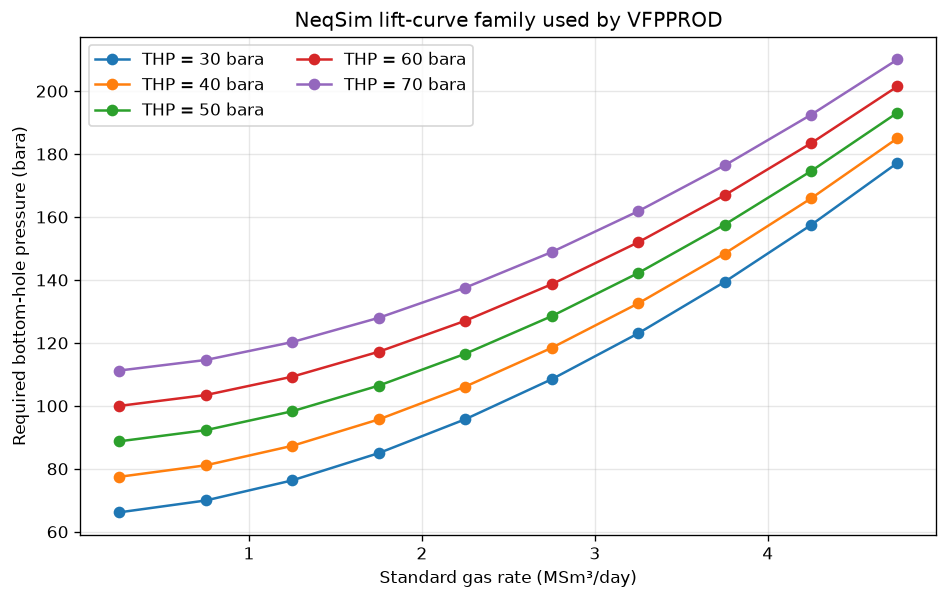

In [11]:
plt.figure(figsize=(8.0, 5.1))
for thp_index, thp_bara in enumerate(vfp_thp_bara):
    plt.plot(
        vfp_flow_rates_msm3_day,
        vfp_bhp_bara[:, thp_index],
        marker="o",
        label=f"THP = {thp_bara:.0f} bara",
    )

plt.xlabel("Standard gas rate (MSm³/day)")
plt.ylabel("Required bottom-hole pressure (bara)")
plt.title("NeqSim lift-curve family used by VFPPROD")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

Each coloured line is one tubing-head-pressure branch. At fixed rate, raising surface
backpressure raises the required bottom-hole pressure. At fixed tubing-head pressure,
raising rate increases the frictional requirement. These two monotonic directions are
important table-quality checks before export.

In [12]:
bhp_table_5d = np.empty(
    (
        len(vfp_flow_rates_sm3_day),
        len(vfp_thp_bara),
        1,
        1,
        1,
    )
)
bhp_table_5d[:, :, 0, 0, 0] = vfp_bhp_bara

java_double_5d = jpype.JArray(jpype.JDouble, 5)
exporter = EclipseVFPExporter(11)
exporter.setTableTitle(
    "Synthetic gas producer nodal-analysis lift table"
)
exporter.setDatumDepth(TUBING_LENGTH_M)
exporter.setFlowRateType("GAS")
exporter.setUnitSystem("METRIC")
exporter.setFlowRates(vfp_flow_rates_sm3_day)
exporter.setTHPs(vfp_thp_bara)
exporter.setWaterCuts([0.0])
exporter.setGORs([0.0])
exporter.setALQs([0.0])
exporter.setBHPTable(
    java_double_5d(bhp_table_5d.tolist())
)

vfpprod_text = str(exporter.getVFPPRODString())
vfpprod_path = Path(
    "/tmp/PRODUCER_A_VFPPROD.inc"
)
vfpprod_path.write_text(
    vfpprod_text,
    encoding="utf-8",
)

print(f"Wrote {vfpprod_path}")
print(f"Characters: {len(vfpprod_text)}")
print(f"5D BHP shape: {bhp_table_5d.shape}")

Wrote /tmp/PRODUCER_A_VFPPROD.inc
Characters: 920
5D BHP shape: (10, 5, 1, 1, 1)


In [13]:
vfpprod_lines = vfpprod_text.splitlines()
print("\n".join(vfpprod_lines[:24]))

---------------------------------------------------------------------------
-- Synthetic gas producer nodal-analysis lift table
-- Generated by NeqSim EclipseVFPExporter
-- Units: METRIC
---------------------------------------------------------------------------
VFPPROD

  11  2800  'GAS'  'WCT'  'GOR'  /
  2.50E+05  7.50E+05  1.25E+06  1.75E+06  2.25E+06  2.75E+06  
  3.25E+06  3.75E+06  4.25E+06  4.75E+06  
/
  30  40  50  60  70  
/
  0
/
  0
/
  0
/
  1  1  1  1  66.17  69.94  76.32  84.98  95.73  108.44  123.01  139.37  157.45  177.20 /
  2  1  1  1  77.46  81.11  87.30  95.69  106.10  118.41  132.53  148.38  165.90  185.04 /
  3  1  1  1  88.73  92.28  98.28  106.42  116.53  128.48  142.18  157.57  174.57  193.14 /
  4  1  1  1  99.99  103.43  109.27  117.18  127.01  138.63  151.95  166.90  183.43  201.49 /
  5  1  1  1  111.22  114.58  120.26  127.96  137.53  148.84  161.81  176.37  192.47  210.05 /


The exported block contains, in order:

1. the `VFPPROD` keyword and table header;
2. the gas-rate axis;
3. the tubing-head-pressure axis;
4. the single fixed-zero WCT, GOR, and ALQ axes; and
5. one indexed BHP row per tubing-head pressure.

The file is an educational ECLIPSE-style include. Before using it in a reservoir model,
confirm the target simulator's rate and pressure units, datum-depth convention, phase-rate
definition, extrapolation policy, and required WCT/WGR, GOR/OGR, and ALQ coverage.

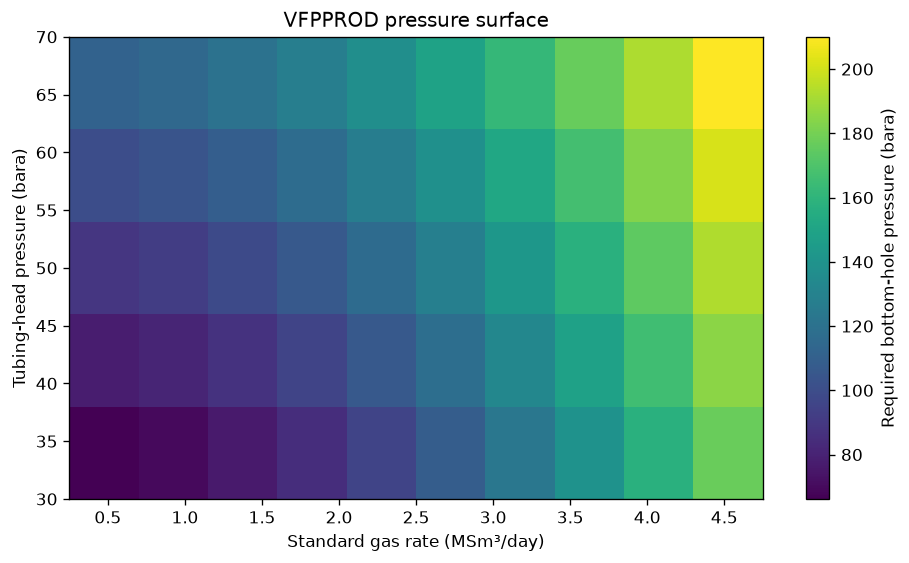

In [14]:
plt.figure(figsize=(8.0, 4.8))
image = plt.imshow(
    vfp_bhp_bara.T,
    aspect="auto",
    origin="lower",
    extent=[
        vfp_flow_rates_msm3_day[0],
        vfp_flow_rates_msm3_day[-1],
        vfp_thp_bara[0],
        vfp_thp_bara[-1],
    ],
    cmap="viridis",
)
plt.colorbar(
    image,
    label="Required bottom-hole pressure (bara)",
)
plt.xlabel("Standard gas rate (MSm³/day)")
plt.ylabel("Tubing-head pressure (bara)")
plt.title("VFPPROD pressure surface")
plt.tight_layout()
plt.show()

## 9. Engineering validation

The final gate checks thermodynamic setup, curve directions, uniqueness and closure of the
operating-point root, agreement with the integrated solver, expected sensitivity trends,
the five-dimensional table mapping, and the exported include structure.

In [15]:
checks = []


def check(condition, description):
    assert bool(condition), description
    checks.append(description)


check(neqsim_version == "3.16.0", "NeqSim version is recorded")
check(
    abs(sum(GAS_COMPOSITION.values()) - 1.0) < 1.0e-12,
    "Gas composition closes",
)
check(
    reservoir_fluid.getNumberOfPhases() == 1,
    "Reservoir fluid is single phase",
)
check(
    np.all(np.diff(ipr_rate_msm3_day) > 0.0),
    "IPR rate grid is increasing",
)
check(
    np.all(np.diff(ipr_bhp_bara) < 0.0),
    "IPR pressure falls with rate",
)
check(
    np.all(np.diff(vlp_bhp_bara) > 0.0),
    "Base VLP pressure rises with rate",
)
check(
    len(
        np.where(
            curve_table["Pressure residual (bar)"].to_numpy()[:-1]
            * curve_table[
                "Pressure residual (bar)"
            ].to_numpy()[1:]
            <= 0.0
        )[0]
    )
    == 1,
    "Exactly one IPR-VLP crossing is bracketed",
)
check(
    abs(crossing["pressure_residual_bar"]) < 1.0e-8,
    "Independent crossing pressure closes",
)
check(
    crossing["rate_bracket_msm3_day"] < 1.0e-12,
    "Independent rate bracket converges",
)
check(
    abs(
        crossing["rate_msm3_day"]
        - api_operating_rate_msm3_day
    )
    < 1.0e-3,
    "Independent crossing agrees with WellSystem.run()",
)
check(
    crossing["ipr_bhp_bara"]
    > TUBING_HEAD_PRESSURE_BARA,
    "Operating BHP exceeds tubing-head pressure",
)
check(
    crossing["ipr_bhp_bara"]
    < RESERVOIR_PRESSURE_BARA,
    "Operating BHP is below reservoir pressure",
)
check(
    np.all(
        np.diff(
            thp_sensitivity[
                "Operating rate (MSm³/day)"
            ]
        )
        < 0.0
    ),
    "Higher tubing-head pressure reduces rate",
)
check(
    np.all(
        np.diff(
            diameter_sensitivity[
                "Operating rate (MSm³/day)"
            ]
        )
        > 0.0
    ),
    "Larger tubing increases rate",
)
check(
    np.all(
        np.diff(
            depletion_sensitivity[
                "Operating rate (MSm³/day)"
            ]
        )
        < 0.0
    ),
    "Operating rate falls as reservoir pressure declines",
)
check(
    bhp_table_5d.shape
    == (
        len(vfp_flow_rates_sm3_day),
        len(vfp_thp_bara),
        1,
        1,
        1,
    ),
    "BHP table has ECLIPSE axis order",
)
check(
    np.all(np.diff(vfp_bhp_bara, axis=0) > 0.0),
    "VFP BHP rises with flow",
)
check(
    np.all(np.diff(vfp_bhp_bara, axis=1) > 0.0),
    "VFP BHP rises with tubing-head pressure",
)
check(
    np.all(vfp_bhp_bara > vfp_thp_bara[np.newaxis, :]),
    "All VFP bottom-hole pressures exceed THP",
)
check(
    vfpprod_text.count("VFPPROD") == 1,
    "Export contains one VFPPROD keyword",
)
check(
    vfpprod_text.count("'GAS'") == 1,
    "Export records the gas-rate type",
)
check(
    sum(
        line.strip().startswith(
            f"{row_index}  1  1  1"
        )
        for row_index in range(
            1,
            len(vfp_thp_bara) + 1,
        )
        for line in vfpprod_lines
    )
    == len(vfp_thp_bara),
    "Export has one indexed BHP row per THP",
)
check(
    vfpprod_path.read_text(encoding="utf-8")
    == vfpprod_text,
    "Written include matches exporter output",
)

print(f"Operating rate: {crossing['rate_msm3_day']:.6f} MSm³/day")
print(f"Operating BHP: {crossing['ipr_bhp_bara']:.6f} bara")
print(f"VFPPROD table shape: {bhp_table_5d.shape}")
print(f"All {len(checks)} engineering checks passed.")

Operating rate: 3.329307 MSm³/day
Operating BHP: 144.511799 bara
VFPPROD table shape: (10, 5, 1, 1, 1)
All 23 engineering checks passed.


## 10. Interpretation and limitations

The base case has one physically meaningful steady operating point. Surface backpressure
and reservoir depletion reduce the rate; a larger tubing bore increases it. The exported
VFP surface preserves the same model behaviour across the chosen rate and tubing-head
pressure grid.

This is a steady screening model, not a well-test regression or completion design. It does
not include reservoir boundaries, transient cleanup, rate-dependent skin, perforations,
gas lift, choke performance, liquid loading, slugging, scale, erosion, corrosion, hydrate
risk, integrity limits, or uncertainty. Avoid extrapolating outside the sampled VFP axes.
Use field pressure surveys and a qualified multiphase model before design, reserves, or
operating decisions.

## 11. Exercises and next steps

1. Replace the PI inflow model with Fetkovich or backpressure parameters from a synthetic
   multi-rate test and compare the operating point.
2. Add condensate and water, then regenerate the VFP table with meaningful WGR and OGR
   axes.
3. Replace the screening VLP with a calibrated segmented Beggs–Brill model and quantify
   table differences.
4. Add a surface choke and separator pressure, and solve the complete well-to-facility
   backpressure problem.
5. Add more rate and THP samples until interpolation error is below a stated tolerance.

## References

- [Field Development and Operations with NeqSim](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html)
- [NeqSim well simulation guide](https://equinor.github.io/neqsim/simulation/well_simulation_guide)
- [NeqSim flow-rate optimization and lift-curve export](https://equinor.github.io/neqsim/process/optimization/flow-rate-optimization)
- [NeqSim `WellSystem` source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/reservoir/WellSystem.java)
- [NeqSim `EclipseVFPExporter` source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/util/optimizer/EclipseVFPExporter.java)